# 02 · 逆向设计：KMD 成分路径优化器

第一节课我们训练了一个正向模型：**成分 → 性质**。这一节把箭头反过来。

> **给定一组性质要求，找出满足它们的化学成分。**

要点先说清楚：我们**不**训练任何新模型。01 训练好的那个模型原封不动、参数全部冻结，
在这里扮演一个「评委」。真正被优化的是**配方本身**。

## 本篇的路线图

| 节 | 内容 |
|---|---|
| 1 | 载入 01 的模型 |
| 2 | **KMD 成分路径优化器的原理**——计算图、为什么在成分空间做、目标函数怎么写 |
| 3 | **重要参数详解**——每个参数解决什么问题，配对照实验 |
| 4 | 选种子：从哪里出发 |
| 5 | 跑三个设计场景，保存中间结果 |
| 6 | 可视化分析：单条结果怎么读、三个场景横向比 |

## 只讲一种优化器

这套代码里有两条逆向设计路线：

- **latent 路径** — 在 encoder 的隐空间里优化 `h`，再用一个自编码器把 `h` 解码回描述符，
  最后用二次规划从描述符反解出成分。三步，每步都有损耗。
- **KMD 成分路径**（本篇）— 直接优化元素权重向量 `w`。一步到位。

**本教材只讲成分路径**，理由在第 2.2 节。这也是 01 里 `enable_autoencoder=False` 的原因——
成分路径根本用不到自编码器。

In [1]:
from __future__ import annotations

import ast
import json
import time
from collections import Counter
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from loguru import logger

from foundation_model.models.flexible_multi_task_model import FlexibleMultiTaskModel, OptimizationTarget
from foundation_model.utils.kmd_plus import DEFAULT_ELEMENTS, KMD, element_features, formula_to_composition

HERE = Path.cwd() if Path.cwd().name == "teaching_inverse_design" else Path("notebooks/teaching_inverse_design")
DATA_PATH = HERE / "data" / "qc_inverse_design_teaching.parquet"
OUT_DIR = HERE / "outputs"

# 图里一律用英文标签（同 01：matplotlib 默认字体没有中文字形）。
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(2025)
np.random.seed(2025)

# 模型加载时会把整个网络结构打进日志，几百行，这里静音掉。
logger.remove()

assert (OUT_DIR / "multitask_model.ckpt").exists(), "找不到 01 的产物 —— 请先完整跑一遍 01_multitask_model.ipynb"

---
## 1 · 载入 01 训练好的模型

`load_from_checkpoint` 会连同结构配置一起恢复，不需要在这里重新写一遍 encoder / head 的定义。

In [2]:
meta = json.loads((OUT_DIR / "model_meta.json").read_text(encoding="utf-8"))
model = FlexibleMultiTaskModel.load_from_checkpoint(OUT_DIR / "multitask_model.ckpt", map_location="cpu")
model.eval()                                   # 关掉 dropout / BN 的训练行为
for p in model.parameters():
    p.requires_grad_(False)                    # 模型是常量：这里只优化成分，不训练网络

CLASSES = meta["classes"]
QC = meta["qc_class_index"]
print("任务头  :", list(model.task_heads.keys()))
print("描述符维度:", meta["x_dim"], " latent:", meta["latent_dim"])
print("类别    :", CLASSES, f"-> QC 的下标是 {QC}")
print("\n01 记录的 test 集表现（决定下面哪些目标可信）:")
print(json.dumps(meta["test_metrics"], indent=2, ensure_ascii=False))

任务头  : ['formation_energy', 'magnetization', 'tc', 'klat', 'material_type']
描述符维度: 464  latent: 128
类别    : ['AC', 'QC', 'others'] -> QC 的下标是 1

01 记录的 test 集表现（决定下面哪些目标可信）:
{
  "formation_energy": {
    "R2": 0.956,
    "MAE": 0.157,
    "n_test": 1280
  },
  "magnetization": {
    "R2": 0.707,
    "MAE": 0.398,
    "n_test": 223
  },
  "tc": {
    "R2": 0.792,
    "MAE": 0.32,
    "n_test": 1545
  },
  "klat": {
    "R2": 0.619,
    "MAE": 0.429,
    "n_test": 902
  },
  "material_type": {
    "accuracy": 0.9792,
    "macro_f1": 0.8375,
    "recall_per_class": {
      "AC": 0.7059,
      "QC": 0.9565,
      "others": 0.9854
    }
  }
}


In [3]:
# 重建和 01 完全一样的 KMD。核矩阵 K 是优化器的必备输入。
kmd = KMD(element_features.values, method="1d", n_grids=meta["n_grids"], sigma="auto", scale=True)
K = kmd.kernel_torch(dtype=torch.float32)      # (94, 464)
print("K:", tuple(K.shape), "  <- (元素数, 描述符维度)")

df = pd.read_parquet(DATA_PATH)
split = pd.read_parquet(OUT_DIR / "resolved_split.parquet")["split"]
print("成分总数:", len(df), " test 集:", int((split == 'test').sum()))

K: (94, 464)   <- (元素数, 描述符维度)
成分总数: 29802  test 集: 4556


---
## 2 · 原理：优化器到底在优化什么

### 2.1 计算图

一句话概括整条链路：

```
logits ──softmax──▶  w  ──@K──▶  x  ──encoder──▶ latent ──tanh──▶ h ──heads──▶ 预测 ──▶ loss
  ↑                  配方        描述符                                                  │
  └──────────────────────── 梯度一路反传回来 ◀──────────────────────────────────────────┘
   （唯一的可训练变量）
```

**被优化的变量是 `logits`，形状 `(B, 94)`，B 是同时设计的配方条数。** 网络参数全部冻结。

每一步：

1. `w = softmax(logits)` — 把任意实数向量变成一个合法配方；
2. `x = w @ K` — 01 第 2 节讲过的那次矩阵乘法，线性、可微；
3. `x → encoder → tanh → h → 各个 head` — 得到当前配方的预测性质；
4. 和目标比，算 loss，`loss.backward()`，Adam 更新 `logits`。

跑 `steps` 步（默认 300），最后一次的 `w` 就是设计结果。

### 2.2 为什么 softmax 是关键一招

一个「配方」必须满足两件事：**每个元素的比例非负**，且**加起来等于 1**。
用数学的话说，`w` 必须落在 94 维单纯形上。

如果直接把 `w` 当作优化变量，每走一步都要投影回单纯形，麻烦且容易卡在边界。
softmax 把这个约束**变成结构的一部分**——不管 `logits` 是什么鬼数字，
`softmax(logits)` 永远是合法配方。约束不需要维护，它是免费的。

In [4]:
# softmax 把任意实数变成合法配方：无论 logits 多离谱，w 都非负且和为 1
demo_logits = torch.tensor([[1.2, -0.4, 0.6, -2.0, 0.9]])
demo_w = torch.softmax(demo_logits, dim=-1)
print("logits :", demo_logits.numpy().round(2))
print("w      :", demo_w.numpy().round(4))
print("w >= 0 :", bool((demo_w >= 0).all()), "   w.sum() =", float(demo_w.sum()))

logits : [[ 1.2 -0.4  0.6 -2.   0.9]]
w      : [[0.3949 0.0797 0.2167 0.0161 0.2925]]
w >= 0 : True    w.sum() = 1.0000001192092896


### 2.3 为什么走成分路径，而不是 latent 路径

| | latent 路径 | **KMD 成分路径（本篇）** |
|---|---|---|
| 优化变量 | 隐向量 `h` | 元素权重 `w` |
| 拿到成分要几步 | `h` →(自编码器解码)→ `x` →(二次规划反解)→ `w`，**两次有损转换** | 不用转，**`w` 本身就是答案** |
| 合法性 | 解码出来的 `x` 未必对应任何真实配方，反解后还得检查 | 天然在单纯形上，**永远合法** |
| 能不能加化学约束 | 难——约束要写在 `h` 上，而 `h` 没有化学含义 | 容易——「只用这些元素」「最多 5 种」都是对 `w` 的直接约束 |
| 需要自编码器 | **需要** | 不需要 |

第三行是本教材选它的核心理由：**约束写在有化学含义的变量上才写得出来。**
「这个配方最多只能有 5 种元素」在 `w` 上是一句话；在 `h` 上你根本无从下手。
而第 3 节会看到，正是这些约束把「模型喜欢但没法合成的东西」变成「实验室能试一试的东西」。

### 2.4 目标函数：`OptimizationTarget`

一个设计场景 = 若干个 `OptimizationTarget` 相加。每一个描述「哪个性质、要它怎么样」。
具体形态由**这个任务的 head 类型**决定，不用你指定：

| head 类型 | 写法 | 通道值（人看的） | loss 项 |
|---|---|---|---|
| 回归 | `value=-2.0` | 预测值 $\hat y$ | $w\,(\hat y - v)^2$ |
| 回归 | `direction="high"` / `"low"` | 预测值 $\hat y$ | $w\,(\mp\hat y)$，无下界 |
| 分类 | `classes=[1]`（默认 high） | $P(\text{这些类})$ | $-w\log P$ |
| 核回归 | `points=[[t,y],…]` | 到目标曲线的 RMSE | $w\cdot\text{MSE}$ |

`weight` 调各项之间的相对轻重。总目标 = 各项之和，**越小越好**。

> **`value` 和 `direction` 的区别很重要**：
> `value=-2.0` 有一个稳定点，到了 -2.0 这一项的梯度就为 0，不会再往下压；
> `direction="low"` 没有下界，`steps × lr` 越大它压得越狠，会一路压到把别的目标挤垮。
> 本教材三个场景全用 `value`，好处是各项之间的平衡是可控的。
>
> 我们的四个性质列都是 z-score，所以 `value=-2.0` 读作「比平均低两个标准差」。

### 2.5 一个最小可运行的例子

一条配方、一个目标，看 loss 是不是真的降下去了。这就是 `optimize_composition` 内部在做的事，
只是它另外还处理了初始化、各种约束和退火。

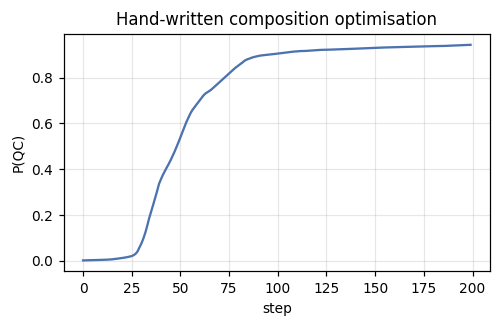

P(QC): 0.0012 -> 0.9428
得到的配方: Mn18.0  He15.6  Li9.3  Zn8.0  Ti6.4  V5.7


In [5]:
# 手写版：从均匀分布出发，只优化一个目标 —— 让模型认为它是 QC
logits = torch.zeros(1, len(DEFAULT_ELEMENTS), requires_grad=True)
opt = torch.optim.Adam([logits], lr=0.05)
history = []
for step in range(200):
    w = torch.softmax(logits, dim=-1)          # ① 合法配方
    x = w @ K                                  # ② KMD 描述符（线性！）
    h = torch.tanh(model.encoder(x))           # ③ 编码
    log_p = torch.log_softmax(model.task_heads["material_type"](h), dim=-1)
    loss = -log_p[:, QC].mean()                # ④ 最大化 P(QC) 等价于最小化 -log P(QC)
    opt.zero_grad(); loss.backward(); opt.step()
    history.append(float(torch.exp(-loss).detach()))

fig, ax = plt.subplots(figsize=(5, 2.8))
ax.plot(history, color="#4C72B0")
ax.set_xlabel("step"); ax.set_ylabel("P(QC)")
ax.set_title("Hand-written composition optimisation")
plt.show()

w_final = torch.softmax(logits, dim=-1).detach().numpy()[0]
top = np.argsort(w_final)[::-1][:6]
print("P(QC):", round(history[0], 4), "->", round(history[-1], 4))
print("得到的配方:", "  ".join(f"{DEFAULT_ELEMENTS[i]}{w_final[i] * 100:.1f}" for i in top if w_final[i] > 1e-3))

这个配方大概率是**不能用的**——它可能有十几种元素、包含惰性气体或放射性元素、
比例也不像任何真实合金。因为我们只告诉了优化器一件事：「让 P(QC) 高」。
它老老实实照做了。

**这正是第 3 节存在的理由：把「化学上说得通」这件事，翻译成优化器听得懂的约束。**

---
## 3 · 重要参数详解

`optimize_composition` 的参数不少，但它们各自解决一个很具体的问题。
按「解决什么问题」分成四组来讲。

调用长这样：

```python
result = model.optimize_composition(
    K,                              # KMD 核矩阵，唯一的位置参数
    targets=[...],                  # 组 1：要什么
    initial_weights=..., seed_blend=...,          # 组 2：从哪出发
    allowed_elements=..., max_elements=...,       # 组 3：能做出来吗
    diversity_scale=..., min_nonzero_weight=..., fixed_amounts=...,
    annealing_scale=...,                          # 组 4：怎么搜
    steps=..., lr=...,
)
```

### 组 1 · 要什么：`targets`

第 2.4 节已经讲过。补一句 `weight` 的用法：三个目标里 `material_type` 我们给 `weight=5.0`，
因为「是不是准晶」是这三个场景共同的**主目标**，形成能和磁化是附加要求。
不加权的话，两个平方项（量级可以到 4~9）会把交叉熵项（量级 0.2~2）淹没。

### 组 2 · 从哪出发：`initial_weights` + `seed_blend`

第 2.5 节从均匀分布出发，得到的东西没法用。更好的做法是**从已知的真实材料出发**——
这些起点叫**种子（seed）**。

- `initial_weights`：`(B, 94)` 的种子配方矩阵。传 `None` 则随机生成 `n_starts` 个起点。
- `seed_blend`：种子的「粘性」，取值 `[0, 1]`。

  $$w_0 = \texttt{seed\_blend} \cdot \text{seed} + (1 - \texttt{seed\_blend}) \cdot \text{uniform}$$

  这个混合有个**不显然但很关键**的作用。种子里没出现的元素，其 `w` 是 0，取 log 后是
  $\log(10^{-12}) \approx -27.6$；Adam 在几百步内根本不可能把它抬起来——
  也就是说 `seed_blend=1.0` 时，**优化器永远无法引入种子里没有的新元素**，
  只能在种子已有的元素之间重新分配比例。
  掺 5% 的均匀分布，把这些 logits 抬到 $\log(0.05/94) \approx -7.5$，新元素才有机会进来。

  所以：`1.0` = 严格守着种子的元素集合；`0.95`（默认）= 允许发现新元素；`0.0` = 种子失效。

### 组 3 · 做得出来吗：`allowed_elements` / `max_elements` / `diversity_scale` / …

这一组是全篇最有实用价值的部分。**没有它们，逆向设计只是数学游戏。**

#### `allowed_elements` — 元素白名单

`"all"`（默认）= 94 个元素随便用，包括惰性气体、放射性元素、剧毒元素。
传一个元素符号列表，就把优化限制在这些元素里：不在名单上的元素，
其 logits 在每一步 softmax 之前被置成 $-\infty$，**梯度永远抬不起它们**。

下一格给出一份 48 元素的合金白名单，筛掉了不适合合金实验的元素
（惰性气体、放射性元素、卤素、碱金属等）。本教材后面一律用它。

#### `max_elements` — 最多几种元素（**本教材的重点**）

这是最实用的一个约束。一个 12 元素的「配方」在实验室里是没有意义的；
三元、五元合金才是可以称量、可以熔炼、可以复现的东西。

难点在于「非零元素个数」是个**离散**的量，不可微。做法不是事后砍掉小的
（那样砍完性质就全变了），而是让约束**全程参与优化**：

每一步用同一批 logits 算出一个软 K-hot 掩码 $m \in [0,1]^{94}$，满足 $\sum m = K$
（Plötz & Roth, NeurIPS 2018 的迭代 softmax），然后

$$w = \frac{\text{softmax}(\text{logits}) \odot m}{\sum \text{softmax}(\text{logits}) \odot m}$$

温度 $\tau$ 控制这个掩码有多「硬」：$\tau$ 大 → 掩码接近均匀，约束很松，
梯度可以在不同的「哪 K 个元素」方案之间流动；$\tau$ 小 → 掩码接近 one-hot，约束变硬。
循环结束后再做一次硬性 top-K 投影，保证**最多** K 个非零元素。

#### `annealing_scale` — 退火，配合 `max_elements` 用

$\tau$ 从大到小几何衰减，`annealing_scale ∈ [0,1]` 一个旋钮控制起点：
`0.0` → $\tau_{\text{start}}=1$（一上来就硬，几乎不探索）；
`0.5` → $\tau_{\text{start}}=5$（默认，经验最优）；
`1.0` → $\tau_{\text{start}}=25$（软阶段最长，探索最充分）。

这同时是一种 **continuation method**：先在放松的问题上找个好区域，再逐步收紧到原问题，
比一上来就解硬问题更容易跳出局部最优。`max_elements=None` 时这个参数无效。

#### `diversity_scale` — 每个配方里元素的「铺开程度」

`1.0`（默认）= 不惩罚；`0.0` = 强惩罚，逼出少元素的尖锐配方。
实现是给 loss 加一项 $(1-\texttt{diversity\_scale})\cdot H(w)$，$H$ 是香农熵。

> ⚠️ 这是**每个配方内部**的复杂度旋钮，**不是**「让 B 个输出彼此不同」的旋钮。
> 想让结果之间有差异，靠的是给不同的种子，不是这个参数。

和 `max_elements` 的区别：`max_elements` 是**硬**上限（保证 ≤ K），
`diversity_scale` 是**软**倾向（鼓励集中，但不保证个数）。

#### `min_nonzero_weight` / `fixed_amounts`（了解即可）

- `min_nonzero_weight=0.10`：「要用就至少用 10%」，把痕量元素（Pt 0.5%）清掉。
- `fixed_amounts={"Au": 0.65, "Ga": 0.20}`：钉死某些元素的比例，剩下 15% 让优化器自由分配。
  做「在已知体系上微调」的实验时很有用。

### 组 4 · 怎么搜：`steps` / `lr`

Adam 在 logits 上的步数和学习率。默认 `steps=300, lr=0.05`。
20 条配方跑 300 步不到 1 秒，所以想加就加。

In [6]:
# 48 元素合金白名单：筛掉了不适合合金实验的元素
# （惰性气体、放射性元素、卤素、碱金属等）。
ALLOY_PALETTE = [
    "Mg", "Ca", "B", "Al", "Ga", "In", "Tl", "Si", "Ge", "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co",
    "Ni", "Cu", "Zn", "Y", "Zr", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Cd", "Hf", "Ta", "W", "Re",
    "Os", "Ir", "Pt", "Au", "La", "Ce", "Pr", "Nd", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Yb",
]
print(f"白名单 {len(ALLOY_PALETTE)} 个元素，占全部 {len(DEFAULT_ELEMENTS)} 个的 {len(ALLOY_PALETTE) / len(DEFAULT_ELEMENTS):.0%}")
print("被排除的例子:", [e for e in DEFAULT_ELEMENTS if e not in ALLOY_PALETTE][:20], "...")

白名单 48 个元素，占全部 94 个的 51%
被排除的例子: ['H', 'He', 'Li', 'Be', 'C', 'N', 'O', 'F', 'Ne', 'Na', 'P', 'S', 'Cl', 'Ar', 'K', 'As', 'Se', 'Br', 'Kr', 'Rb'] ...


---
## 4 · 选种子

种子是优化的起点。好的种子 = 已经离目标不太远的**真实**材料，
优化器只需要在它周围做局部改良，而不是从虚无中凭空造一个配方出来。

选法三步：

1. 用 `model.evaluate_targets` 给候选成分打分——这个函数算的就是优化器要最小化的那个目标；
2. 只从 **test 集**里挑。种子必须是模型训练时没背过的成分，
   这样「模型觉得它好」才是一个有信息量的判断，而不是记忆；
3. 分数最低的挑 20 个，按**元素体系**去重——`Mg2Zn3` 和 `Mg4Zn6` 是同一个体系，
   留两个只是浪费一次优化。

### ⚠️ 一个必须踩过才记得住的坑：种子要落在可行域里

第一次写这段代码时我们从**整个** test 集里挑种子，结果 scenario 2 的 objective
优化完反而**变差**了（20.35 → 20.46）。原因值得想清楚：

scenario 2 要高 Tc，而 test 集里 Tc 最高的成分是 `Ba2 Eu1 Cu3 O6.53`、`Ti1 H1.75`、
`Li2 Mn2 P2` 这类**氧化物、氢化物、磷化物**——它们根本不是合金。
这些种子有 50%~84% 的质量落在 48 元素白名单**之外**，
而优化器第一步就会把白名单外的元素强制清零。种子的大半被砍掉，
高 Tc 的来源（H、O、P）也随之消失，Tc 从 +0.54 一路掉到 −0.37。

**教训：挑种子用的可行域，必须和优化器用的可行域一致。**
所以下面的 `select_seeds` 只在「全部元素都在白名单内」的成分里挑。
筛完 test 集 4556 个成分只剩约 800 个，但它们全是真合金
（`Ti46.5 Nb53.5`、`Al59.5 Fe12.2 Cu25.3 B3`、`Yb1 Al8 Fe4`……），
三个场景也就都能正常改善了。

In [7]:
N_SEEDS = 20

# 三个设计场景。共同的主目标是 QC（weight=5），性质目标都取 z-score 下的 ±2。
SCENARIOS = {
    "scenario1_fe_down_magnetic_up": [
        OptimizationTarget(task="material_type", classes=[QC], direction="high", weight=5.0),
        OptimizationTarget(task="formation_energy", value=-2.0),
        OptimizationTarget(task="magnetization", value=2.0),
    ],
    "scenario2_fe_down_tc_up_magnetic_up": [
        OptimizationTarget(task="material_type", classes=[QC], direction="high", weight=5.0),
        OptimizationTarget(task="formation_energy", value=-2.0),
        OptimizationTarget(task="tc", value=2.0),
        OptimizationTarget(task="magnetization", value=2.0),
    ],
    "scenario3_fe_down_klat_up": [
        OptimizationTarget(task="material_type", classes=[QC], direction="high", weight=5.0),
        OptimizationTarget(task="formation_energy", value=-2.0),
        OptimizationTarget(task="klat", value=2.0),
    ],
}
CHANNEL_NAMES = {name: [f"P({CLASSES[QC]})" if t.task == "material_type" else t.task for t in ts]
                 for name, ts in SCENARIOS.items()}

for name, targets in SCENARIOS.items():
    desc = ", ".join(
        f"P({CLASSES[QC]})↑×{t.weight:g}" if t.task == "material_type" else f"{t.task}→{t.value:+g}"
        for t in targets
    )
    print(f"  {name:36s} {desc}")

  scenario1_fe_down_magnetic_up        P(QC)↑×5, formation_energy→-2, magnetization→+2
  scenario2_fe_down_tc_up_magnetic_up  P(QC)↑×5, formation_energy→-2, tc→+2, magnetization→+2
  scenario3_fe_down_klat_up            P(QC)↑×5, formation_energy→-2, klat→+2


In [8]:
def element_system(composition: str) -> frozenset[str]:
    '''"Mg2 Zn3" -> {"Mg", "Zn"}：只看用了哪些元素，不看比例。'''
    return frozenset(tok.rstrip("0123456789.") for tok in composition.split())


# 可行的种子池：test 集 ∩ 全部元素都在白名单内。上面那段说明解释了为什么必须这么筛。
SEED_POOL = [c for c in df["composition"] if split.get(c) == "test" and element_system(c) <= set(ALLOY_PALETTE)]
SEED_POOL_X = torch.tensor(
    kmd.transform(np.stack([formula_to_composition(c) for c in SEED_POOL])), dtype=torch.float32
)
print(f"test 集 {int((split == 'test').sum())} 个成分 -> 白名单内的可行种子池 {len(SEED_POOL)} 个")
print("池子里的例子:", SEED_POOL[:4])


def select_seeds(targets, n=N_SEEDS):
    '''从可行种子池里按场景目标打分，取最好的 n 个，按元素体系去重。'''
    pool, x = SEED_POOL, SEED_POOL_X
    channels, objective = model.evaluate_targets(x, targets)     # (N, T) 和 (N,)
    seen, seeds, idx = set(), [], []
    for i in np.argsort(objective.numpy()):
        system = element_system(pool[int(i)])
        if system in seen:
            continue
        seen.add(system)
        seeds.append(pool[int(i)])
        idx.append(int(i))
        if len(seeds) == n:
            break
    return seeds, channels[idx].numpy(), objective[idx].numpy()


seeds_s1, seed_ch_s1, seed_obj_s1 = select_seeds(SCENARIOS["scenario1_fe_down_magnetic_up"])
preview = pd.DataFrame(seed_ch_s1, columns=CHANNEL_NAMES["scenario1_fe_down_magnetic_up"], index=seeds_s1)
preview.insert(0, "objective", seed_obj_s1)
print("scenario 1 的 20 个种子（objective 越小越好）:")
display(preview.round(3))

test 集 4556 个成分 -> 白名单内的可行种子池 808 个
池子里的例子: ['B1', 'Cr1.5 B105', 'V1.3 B105', 'V3.7 B96.3']
scenario 1 的 20 个种子（objective 越小越好）:


,objective,P(QC),formation_energy,magnetization
Al66.6 Re10.3 Pd23.1,13.338,0.988,1.025,-0.031
Al59.5 Fe12.2 Cu25.3 B3,13.521,0.995,1.150,0.111
Al71 Co0.9 Re8.1 Pd20,13.647,0.987,1.075,-0.031
Al71 Fe1.8 Re7.2 Pd20,13.699,0.985,1.085,-0.027
Al71 Re5.4 Pd20 Ru3.6,13.728,0.950,1.054,-0.036
Al66 Ga4 Re10 Pd20,13.733,0.990,1.093,-0.029
Mn4.52 Al70.09 Re5.9 Pd19.49,13.734,0.985,1.096,-0.019
Al54 Fe12.5 Cu25.5 Si8,13.793,0.992,1.111,-0.019
Al54 Cu25.5 Si8 Ru12.5,13.859,0.972,1.068,-0.075
Mn10 Al70 Pd20,13.872,0.966,1.106,-0.013


### 3 节的对照实验

有了种子，现在可以做第 3 节承诺的对照实验：**同一批种子、同一个目标，每次只改一个参数**。

In [9]:
targets_s1 = SCENARIOS["scenario1_fe_down_magnetic_up"]
W_seed = torch.tensor(np.stack([formula_to_composition(c) for c in seeds_s1]), dtype=torch.float64)

BASELINE = dict(
    initial_weights=W_seed, seed_blend=0.95, targets=targets_s1,
    allowed_elements=ALLOY_PALETTE, max_elements=5, annealing_scale=0.5,
    diversity_scale=1.0, steps=300, lr=0.05,
)


def try_knobs(**overrides):
    kwargs = {**BASELINE, **overrides}
    res = model.optimize_composition(K, **kwargs)
    channels, objective = model.evaluate_targets(res.optimized_descriptor, targets_s1)
    n_elements = (res.optimized_weights > 1e-3).sum(dim=1).float()
    return {
        "objective": float(objective.mean()),
        "P(QC)": float(channels[:, 0].mean()),
        "formation_energy": float(channels[:, 1].mean()),
        "#elements": float(n_elements.mean()),
    }


experiments = [
    ("baseline (palette, K=5)", {}),
    ("max_elements=None", dict(max_elements=None)),
    ("max_elements=3", dict(max_elements=3)),
    ("allowed_elements='all'", dict(allowed_elements="all")),
    ("diversity_scale=0.0", dict(diversity_scale=0.0)),
    ("seed_blend=1.0", dict(seed_blend=1.0)),
    ("random start (no seed)", dict(initial_weights=None, n_starts=N_SEEDS)),
    ("steps=1000", dict(steps=1000)),
    ("annealing_scale=0.0", dict(annealing_scale=0.0)),
]
t0 = time.perf_counter()
knob_table = pd.DataFrame({label: try_knobs(**kw) for label, kw in experiments}).T
print(f"9 组实验共耗时 {time.perf_counter() - t0:.1f} 秒\n")
display(knob_table.round(3))

9 组实验共耗时 6.7 秒



,objective,P(QC),formation_energy,#elements
"baseline (palette, K=5)",11.245,0.842,0.697,5.00
max_elements=None,8.826,0.908,0.556,10.25
max_elements=3,12.082,0.933,0.944,3.00
allowed_elements='all',8.754,0.874,0.248,5.00
diversity_scale=0.0,12.649,0.849,0.843,5.00
seed_blend=1.0,16.240,0.768,1.137,3.60
random start (no seed),12.784,0.756,0.706,5.00
steps=1000,10.800,0.844,0.753,5.00
annealing_scale=0.0,15.483,0.769,0.949,4.85


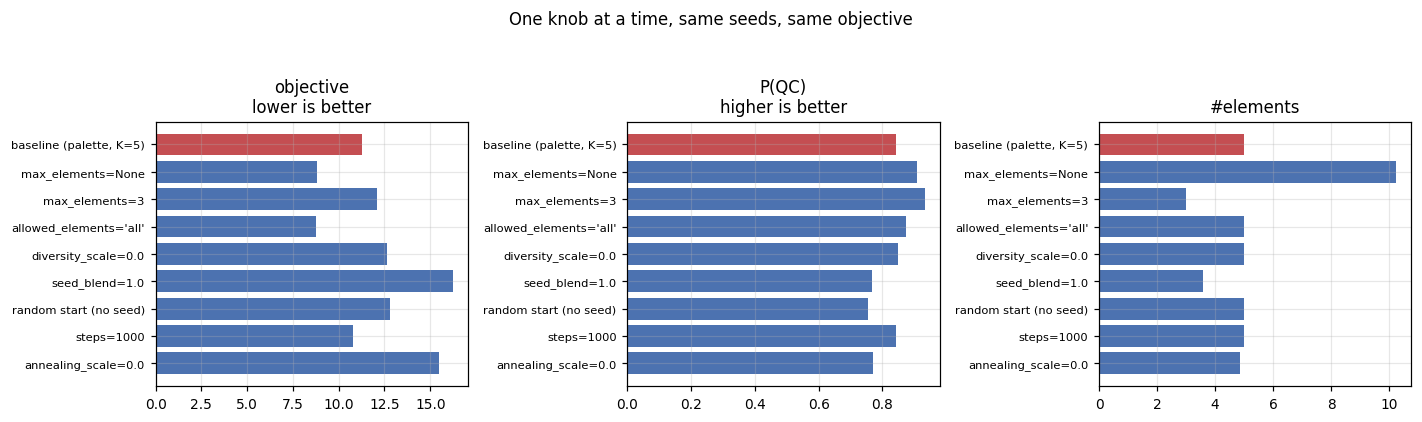

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
colors = ["#C44E52" if lbl.startswith("baseline") else "#4C72B0" for lbl in knob_table.index]
for ax, col, better in zip(axes, ["objective", "P(QC)", "#elements"], ["lower is better", "higher is better", ""]):
    ax.barh(range(len(knob_table)), knob_table[col], color=colors)
    ax.set_yticks(range(len(knob_table)), knob_table.index, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_title(f"{col}\n{better}" if better else col)
fig.suptitle("One knob at a time, same seeds, same objective", y=1.05)
fig.tight_layout()
plt.show()

**怎么读这张表**（具体数字每次跑略有不同，趋势稳定）：

- **`max_elements=None` 的 objective 最好，但元素数接近 9。** 这条最能说明问题：
  约束**一定**会让目标变差，这是必然的——可行域变小了。逆向设计的实际工作
  从来不是「把 objective 压到最低」，而是**在可合成的前提下**尽量低。
- **`max_elements=3` 比 K=5 略差**，但换来的是三元合金——真正能进实验炉的东西。
  从 K=5 到 K=3 付出的代价有多大，正是这个旋钮要回答的问题。
- **`allowed_elements='all'` 的 objective 明显更好。** 别高兴太早：去看看它用了哪些元素。
  模型在训练数据里见过含惰性气体、放射性元素的化合物，它会毫不犹豫地用上去。
  白名单的代价，就是买「这个结果能拿去做实验」的价钱。
- **`seed_blend=1.0` 几乎没有进展。** 印证了第 3 节组 2 的分析：
  锁死在种子的元素集合里，优化器只能调比例，动弹不得。
- **随机起点比种子差**，而且差得明显——种子不是可有可无的加速手段。
- **`steps=1000` 比 300 好一些**，边际收益递减；`annealing_scale=0.0`（不探索）通常更差，
  说明退火确实在帮忙跳出局部最优。

---
## 5 · 跑三个设计场景

三个场景共用同一个「主目标」——让模型认为它是准晶——但附加的性质要求不同：

| 场景 | 附加要求 | 现实动机 |
|---|---|---|
| **1** | 形成能↓ + 磁化↑ | 磁性准晶：既要热力学上稳、又要有磁性 |
| **2** | 形成能↓ + Tc↑ + 磁化↑ | 在 1 的基础上再要超导——**四个目标，冲突最大** |
| **3** | 形成能↓ + 晶格热导率↑ | 导热型准晶（准晶通常热导极低，所以这个要求是逆着材料本性来的） |

所有场景用同一套优化配置——本教材的主角配置：

- `allowed_elements=ALLOY_PALETTE`（48 元素白名单）
- `max_elements=5`（**至多五元合金**）
- `annealing_scale=0.5`、`diversity_scale=1.0`、`seed_blend=0.95`、`steps=600`、`lr=0.05`
  （第 3 节的对照实验里 300 步就够看趋势；正式跑给 600 步，三个场景都还有可观的边际收益，
  代价不过是每个场景多花一秒）

种子**按场景各自重选**：不同的目标，「离目标近」的起点自然不一样。

In [11]:
MAX_ELEMENTS, ANNEALING_SCALE, SEED_BLEND, STEPS, LR = 5, 0.5, 0.95, 600, 0.05
TOP_K = 6   # 展示配方时只列最大的 6 个元素


def format_composition(w: np.ndarray, top_k: int = TOP_K, eps: float = 1e-3) -> dict[str, float]:
    '''取权重最大的几个元素，重新归一化到和为 1 —— 表格和图里显示的就是这个。'''
    order = np.argsort(w)[::-1][:top_k]
    picked = {DEFAULT_ELEMENTS[int(i)]: float(w[int(i)]) for i in order if w[int(i)] > eps}
    total = sum(picked.values())
    return {k: v / total for k, v in picked.items()} if total else picked


def run_scenario(name: str) -> dict:
    targets = SCENARIOS[name]
    seeds, seed_channels, seed_objective = select_seeds(targets)
    w_seed = torch.tensor(np.stack([formula_to_composition(c) for c in seeds]), dtype=torch.float64)

    t0 = time.perf_counter()
    res = model.optimize_composition(
        K,
        initial_weights=w_seed,
        seed_blend=SEED_BLEND,
        targets=targets,
        allowed_elements=ALLOY_PALETTE,
        max_elements=MAX_ELEMENTS,
        annealing_scale=ANNEALING_SCALE,
        diversity_scale=1.0,
        steps=STEPS,
        lr=LR,
        record_weights_trajectory=False,   # 只留目标轨迹，权重轨迹体积大且这里用不到
    )
    elapsed = time.perf_counter() - t0
    channels, objective = model.evaluate_targets(res.optimized_descriptor, targets)
    weights = res.optimized_weights.numpy()

    rows = []
    for i, seed in enumerate(seeds):
        row = {
            "scenario": name,
            "seed_index": i,
            "seed": seed,
            "seed_composition": str(format_composition(formula_to_composition(seed), top_k=None)),
            "optimized_composition": str(format_composition(weights[i])),
            "n_elements": int((weights[i] > 1e-3).sum()),
            "seed_objective": float(seed_objective[i]),
            "optimized_objective": float(objective[i]),
        }
        for j, ch in enumerate(CHANNEL_NAMES[name]):
            row[f"seed_{ch}"] = float(seed_channels[i, j])
            row[f"opt_{ch}"] = float(channels[i, j])
            row[f"delta_{ch}"] = float(channels[i, j] - seed_channels[i, j])
        rows.append(row)

    return {
        "name": name,
        "seeds": seeds,
        "table": pd.DataFrame(rows),
        "weights": weights,
        "seed_channels": seed_channels,
        "channels": channels.numpy(),
        "trajectory": res.trajectory.numpy(),     # (steps, B, T)
        "elapsed": elapsed,
    }


results = {}
for name in SCENARIOS:
    results[name] = run_scenario(name)
    r = results[name]
    print(f"{name}")
    print(f"    {r['elapsed']:.1f} 秒   objective {r['table'].seed_objective.mean():7.3f}"
          f" -> {r['table'].optimized_objective.mean():7.3f}"
          f"   平均元素数 {r['table'].n_elements.mean():.1f}")

scenario1_fe_down_magnetic_up
    1.2 秒   objective  13.909 ->  10.834   平均元素数 5.0


scenario2_fe_down_tc_up_magnetic_up
    1.4 秒   objective  22.270 ->  15.892   平均元素数 5.0


scenario3_fe_down_klat_up
    1.2 秒   objective  10.178 ->   7.768   平均元素数 4.7


### 保存中间结果

每个场景存两个文件：一张逐种子的明细表，和一份优化轨迹。
后面第 6 节的所有分析都只读这些文件——也就是说**分析和优化解耦了**，
你可以关掉 kernel、隔天再来只跑第 6 节。

In [12]:
for name, r in results.items():
    r["table"].to_parquet(OUT_DIR / f"{name}__seed_to_optimized.parquet", index=False)
    np.savez_compressed(
        OUT_DIR / f"{name}__trajectory.npz",
        trajectory=r["trajectory"].astype(np.float32),
        optimized_weights=r["weights"].astype(np.float32),
        channel_names=np.array(CHANNEL_NAMES[name]),
        seeds=np.array(r["seeds"]),
    )

for p in sorted(OUT_DIR.glob("scenario*")):
    print(f"  {p.name:52s} {p.stat().st_size / 1024:7.1f} KB")

print("\nscenario 1 明细表的前几行：")
display(results["scenario1_fe_down_magnetic_up"]["table"].head(4).T)

  scenario1_fe_down_magnetic_up__seed_to_optimized.parquet    16.0 KB
  scenario1_fe_down_magnetic_up__trajectory.npz          123.6 KB
  scenario2_fe_down_tc_up_magnetic_up__seed_to_optimized.parquet    18.2 KB
  scenario2_fe_down_tc_up_magnetic_up__trajectory.npz    169.9 KB
  scenario3_fe_down_klat_up__seed_to_optimized.parquet    15.7 KB
  scenario3_fe_down_klat_up__trajectory.npz              124.6 KB

scenario 1 明细表的前几行：


,0,1,2,3
scenario,scenario1_fe_down_magnetic_up,scenario1_fe_down_magnetic_up,scenario1_fe_down_magnetic_up,scenario1_fe_down_magnetic_up
seed_index,0,1,2,3
seed,Al66.6 Re10.3 Pd23.1,Al59.5 Fe12.2 Cu25.3 B3,Al71 Co0.9 Re8.1 Pd20,Al71 Fe1.8 Re7.2 Pd20
seed_composition,"{'Al': 0.6659999999999999, 'Pd': 0.231, 'Re': ...","{'Al': 0.595, 'Cu': 0.253, 'Fe': 0.122, 'B': 0...","{'Al': 0.71, 'Pd': 0.2, 'Re': 0.081, 'Co': 0.0...","{'Al': 0.71, 'Pd': 0.2, 'Re': 0.07200000000000..."
optimized_composition,"{'Al': 0.47637863031876004, 'Re': 0.2564779279...","{'Al': 0.33633451902118655, 'Mn': 0.2255890915...","{'Al': 0.3125228355643787, 'Re': 0.28563228887...","{'Mg': 0.5914946728405207, 'Re': 0.21925270312..."
n_elements,5,5,5,5
seed_objective,13.337673,13.521437,13.646685,13.698943
optimized_objective,11.436025,10.503458,9.929995,10.709801
seed_P(QC),0.987995,0.994559,0.986835,0.985035
opt_P(QC),0.905026,0.945637,0.936107,0.832089


---
## 6 · 可视化分析

四张图，每张回答一个不同的问题。

### 6.1 优化轨迹：过程中发生了什么

`result.trajectory` 的形状是 `(steps, B, T)`——每一步、每条配方、每个目标通道的值。
这是唯一能看见**过程**的图，其他三张看的都是结果。

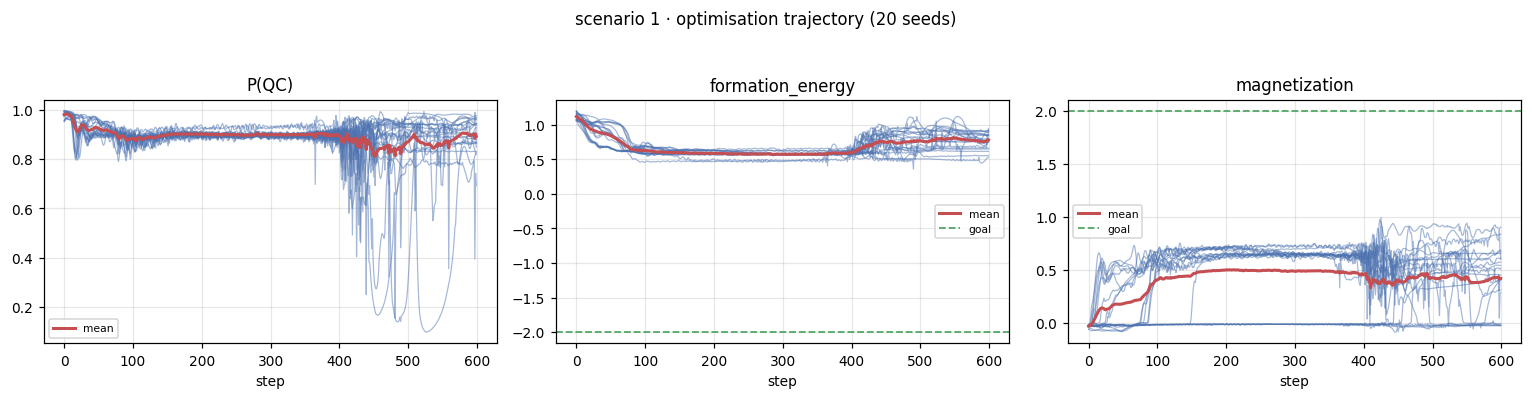

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
r = results["scenario1_fe_down_magnetic_up"]
traj, names = r["trajectory"], CHANNEL_NAMES["scenario1_fe_down_magnetic_up"]
goals = [None, -2.0, 2.0]        # P(QC) 没有固定终点（越高越好），另外两个有
for ax, j in zip(axes, range(traj.shape[2])):
    for b in range(traj.shape[1]):
        ax.plot(traj[:, b, j], lw=0.8, alpha=0.5, color="#4C72B0")
    ax.plot(traj[:, :, j].mean(axis=1), lw=2, color="#C44E52", label="mean")
    if goals[j] is not None:
        ax.axhline(goals[j], color="#55A868", ls="--", lw=1.2, label="goal")
    ax.set_title(names[j]); ax.set_xlabel("step"); ax.legend(fontsize=7)
fig.suptitle("scenario 1 · optimisation trajectory (20 seeds)", y=1.05)
fig.tight_layout()
plt.show()

值得注意的几点：

- **形成能和磁化都没有到达 ±2 的目标线，而且停下来了。** 这不是没收敛，
  是三个目标在互相拉扯 + 约束（白名单 + 至多 5 元）限制了可行域。
  `value` 型目标本来就允许「尽力而为」，不像 `direction` 会一路压到底。
- **P(QC) 前期常常先掉一下再回升。** 形成能项的梯度在开头比交叉熵项猛，
  会把配方拽出准晶区，等退火收紧、几个目标重新平衡后才拉回来。
- 20 条曲线的分散程度反映了**起点的影响**：种子不同，落到的局部解也不同。
  这正是要跑 20 个种子而不是 1 个的原因。

### 6.2 种子 → 优化结果：逐条看设计

信息密度最高的一张图。每行 = 一个种子和它的优化结果，左黑右彩。
右侧元素符号的**颜色**编码「这个元素在本场景 20 条结果里出现了几次」——
深紫 = 只在这一条里出现，橙黄 = 几乎每条都有。
一眼就能看出优化器反复押注的是哪几个元素。

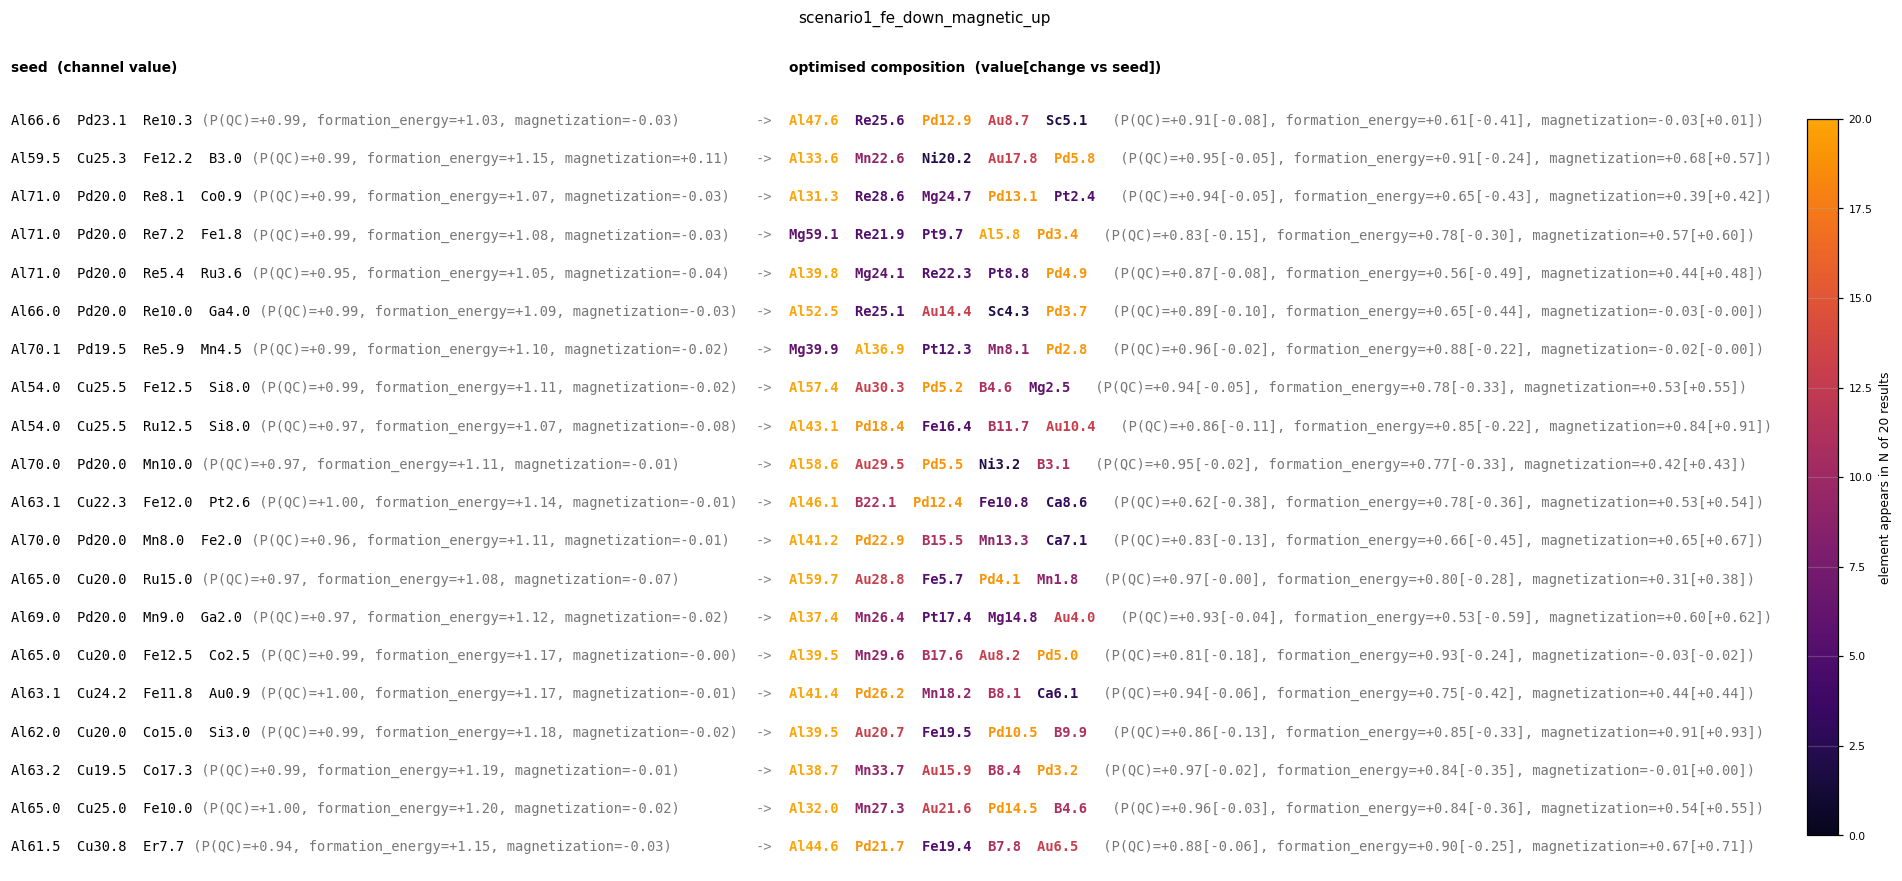

In [14]:
CMAP = mcolors.LinearSegmentedColormap.from_list(
    "elem", plt.get_cmap("inferno")(np.linspace(0.05, 0.80, 256))   # 掐掉两端：纯黑和浅黄在白底上都看不清
)
FONT = 9
CHAR_W = 0.602 * FONT / 72.0   # DejaVu Sans Mono 的字宽（英寸）


def plot_seed_to_optimized(res: dict):
    '''一行一个种子：左边种子，右边优化结果，元素符号按出现频次着色。

    版面按字符数算：等宽字体下「字符数 x 字宽」就是精确的文本宽度，
    所以不管有几个目标通道、公式多长，两列都不会互相压到。
    '''
    table, channels = res["table"], CHANNEL_NAMES[res["name"]]
    seed_comps = [ast.literal_eval(s) for s in table["seed_composition"]]
    opt_comps = [ast.literal_eval(s) for s in table["optimized_composition"]]
    n = len(opt_comps)

    counts = Counter(el for c in opt_comps for el in c)          # 每个元素出现在几条结果里
    colors = {el: CMAP(cnt / n) for el, cnt in counts.items()}
    order = lambda c: sorted(c.items(), key=lambda kv: -kv[1])   # 比例从大到小

    seed_txt = ["  ".join(f"{el}{v * 100:.1f}" for el, v in order(c)) for c in seed_comps]
    seed_sfx = [" (" + ", ".join(f"{ch}={table.loc[i, f'seed_{ch}']:+.2f}" for ch in channels) + ")" for i in range(n)]
    opt_sfx = [" (" + ", ".join(f"{ch}={table.loc[i, f'opt_{ch}']:+.2f}[{table.loc[i, f'delta_{ch}']:+.2f}]"
                                for ch in channels) + ")" for i in range(n)]
    # 右侧要逐元素着色，所以拆成 (文本, 颜色) 片段
    opt_parts = [[(f"{el}{v * 100:.1f}  ", colors[el]) for el, v in order(c)] for c in opt_comps]

    HDR_L, HDR_R = "seed  (channel value)", "optimised composition  (value[change vs seed])"
    w1 = max(max(len(a) + len(b) for a, b in zip(seed_txt, seed_sfx)), len(HDR_L))
    w2 = max(max(sum(len(t) for t, _ in ps) + len(sfx) for ps, sfx in zip(opt_parts, opt_sfx)), len(HDR_R))
    gap = 6                                                       # 中间放箭头的空档（字符数）
    total = w1 + gap + w2

    text_in, cbar_in, pad_in, title_in = total * CHAR_W, 0.28, 0.30, 0.55
    fig_w, fig_h = text_in + pad_in + cbar_in, 0.32 * n + 0.9 + title_in
    body = (fig_h - title_in) / fig_h
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_axes((0.0, 0.0, text_in / fig_w, body))
    cax = fig.add_axes(((text_in + pad_in) / fig_w, 0.04, cbar_in / fig_w, body - 0.10))
    ax.set_xlim(0, total); ax.set_ylim(-1.4, n - 0.4); ax.invert_yaxis(); ax.set_axis_off()
    ax.text(0, -1.2, HDR_L, fontsize=FONT, fontweight="bold", va="bottom")
    ax.text(w1 + gap, -1.2, HDR_R, fontsize=FONT, fontweight="bold", va="bottom")

    mono = dict(fontsize=FONT, family="monospace", va="center")
    for i in range(n):
        ax.text(0, i, seed_txt[i], **mono)
        ax.text(len(seed_txt[i]), i, seed_sfx[i], color="#777", **mono)
        ax.text(w1 + gap / 2, i, "->", color="#888", ha="center", **mono)
        x = w1 + gap
        for text, color in opt_parts[i]:
            ax.text(x, i, text, color=color, fontweight="bold", **mono)
            x += len(text)
        ax.text(x, i, opt_sfx[i], color="#777", **mono)

    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=mcolors.Normalize(vmin=0, vmax=n))
    fig.colorbar(sm, cax=cax).set_label(f"element appears in N of {n} results", fontsize=FONT - 1)
    cax.tick_params(labelsize=FONT - 2)
    fig.suptitle(res["name"], y=0.995, fontsize=FONT + 1)
    plt.show()


plot_seed_to_optimized(results["scenario1_fe_down_magnetic_up"])

怎么读这张图：

1. **看颜色最亮的元素**——它们是优化器在这个目标下反复选中的，是这个场景的「答案骨架」。
   scenario 1 里 Al 和 Pd 几乎每条都有（20/20、19/20），因为种子本来就是 Al-Pd-Re、
   Al-Cu-Fe 这一类真实的准晶形成体系。
2. **看 `[...]` 里的变化量**——正负号对不对（形成能要降就该是负数，磁化要升就该是正数），
   以及幅度有多大。
3. **看左右两侧的元素有没有换过**——`seed_blend=0.95` 允许引入新元素。
   很多行右边出现了 Mn、Au、B、Mg，而左边没有，这些就是优化器主动「发现」的。
   Mn 出现得多不是巧合：它是这个模型学到的「加磁化」的主要手段。
4. **看 P(QC) 那一列几乎都在往下掉一点**（`-0.02` 到 `-0.15`）。
   这是优化器在拿准晶概率换形成能和磁化——`weight=5.0` 决定了它愿意换多少。
   这不是失败，这是多目标优化的本来面目。

### 6.3 元素频率：三个场景各自偏爱什么

把三个场景叠在一起看，就能回答「不同的性质要求，会把设计推向哪些元素」。

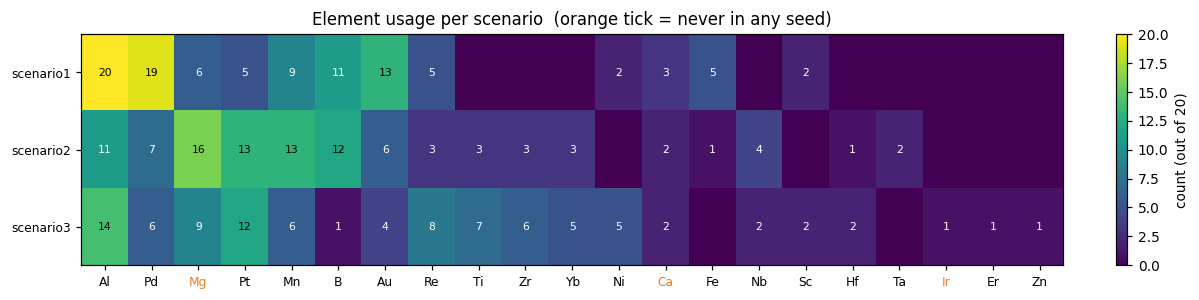

In [15]:
freq = {}
for name, r in results.items():
    counter = Counter(el for s in r["table"]["optimized_composition"] for el in ast.literal_eval(s))
    freq[name.split("_", 1)[0]] = counter
seed_elements = {el for r in results.values() for s in r["table"]["seed_composition"] for el in ast.literal_eval(s)}

all_elements = Counter()
for c in freq.values():
    all_elements.update(c)
top = [el for el, _ in all_elements.most_common(22)]
matrix = np.array([[freq[k].get(el, 0) for el in top] for k in freq])

fig, ax = plt.subplots(figsize=(11, 2.8))
im = ax.imshow(matrix, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(top)), top, fontsize=8)
ax.set_yticks(range(len(freq)), list(freq), fontsize=8)
ax.grid(False)
for tick, el in zip(ax.get_xticklabels(), top):
    if el not in seed_elements:
        tick.set_color("#E67E22")      # 种子里从没出现过 = 优化器自己找出来的
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if matrix[i, j]:
            ax.text(j, i, int(matrix[i, j]), ha="center", va="center", fontsize=7,
                    color="white" if matrix[i, j] < matrix.max() * 0.6 else "black")
fig.colorbar(im, ax=ax, label="count (out of 20)", fraction=0.02)
ax.set_title("Element usage per scenario  (orange tick = never in any seed)")
fig.tight_layout()
plt.show()

**橙色的元素刻度是这张图最有意思的地方**：那些元素在任何一个种子里都没出现过，
是优化器通过 `seed_blend` 留出的 5% 缝隙自己「引入」的。
这是逆向设计相比「在已有材料里筛选」的增量价值——它能提出数据库里没有的组合。

同时也看得出各场景的偏好差异：要磁化的场景会偏向 Mn、Fe、Gd 一类；
要高热导的场景倾向轻元素和简单结构；要超导的场景又是另一批。

### 6.4 三个场景横向对比

最后回到最开始的问题：**这些设计到底有多成功？**

,n_targets,objective (seed),objective (opt),improvement,P(QC) seed,P(QC) opt,mean #elements
scenario,,,,,,,
scenario1,3,13.909,10.834,3.075,0.980,0.893,5.0
scenario2,4,22.270,15.892,6.378,0.893,0.844,5.0
scenario3,3,10.178,7.768,2.411,0.929,0.869,4.7


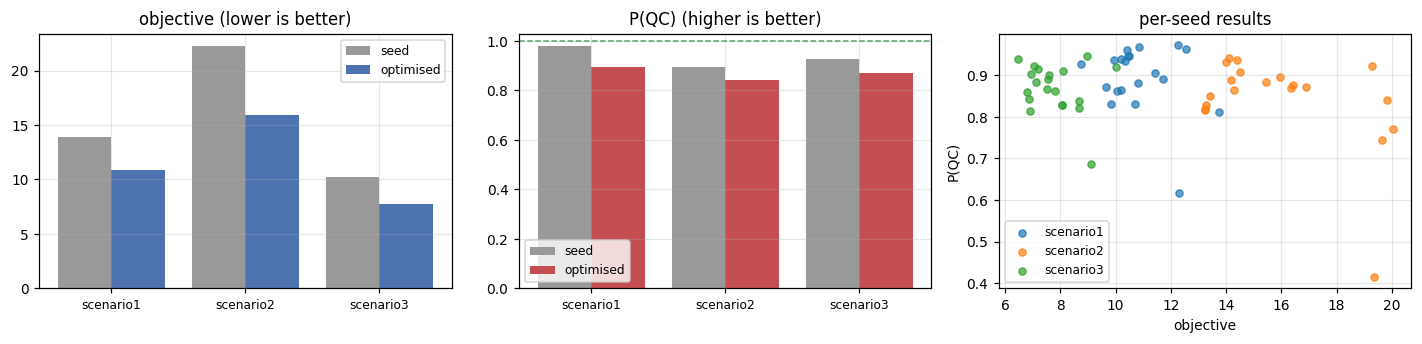

In [16]:
summary = []
for name, r in results.items():
    t = r["table"]
    row = {
        "scenario": name.split("_", 1)[0],
        "n_targets": len(SCENARIOS[name]),
        "objective (seed)": t.seed_objective.mean(),
        "objective (opt)": t.optimized_objective.mean(),
        "improvement": t.seed_objective.mean() - t.optimized_objective.mean(),
        f"P({CLASSES[QC]}) seed": t[f"seed_P({CLASSES[QC]})"].mean(),
        f"P({CLASSES[QC]}) opt": t[f"opt_P({CLASSES[QC]})"].mean(),
        "mean #elements": t.n_elements.mean(),
    }
    summary.append(row)
summary = pd.DataFrame(summary).set_index("scenario")
display(summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
x = np.arange(len(summary))
axes[0].bar(x - 0.2, summary["objective (seed)"], 0.4, label="seed", color="#999999")
axes[0].bar(x + 0.2, summary["objective (opt)"], 0.4, label="optimised", color="#4C72B0")
axes[0].set_title("objective (lower is better)"); axes[0].legend(fontsize=8)

axes[1].bar(x - 0.2, summary[f"P({CLASSES[QC]}) seed"], 0.4, label="seed", color="#999999")
axes[1].bar(x + 0.2, summary[f"P({CLASSES[QC]}) opt"], 0.4, label="optimised", color="#C44E52")
axes[1].axhline(1.0, color="#55A868", ls="--", lw=1)
axes[1].set_title(f"P({CLASSES[QC]}) (higher is better)"); axes[1].legend(fontsize=8)

for name, r in results.items():
    t = r["table"]
    axes[2].scatter(t.optimized_objective, t[f"opt_P({CLASSES[QC]})"], s=22, alpha=0.7,
                    label=name.split("_", 1)[0])
axes[2].set_xlabel("objective"); axes[2].set_ylabel(f"P({CLASSES[QC]})")
axes[2].set_title("per-seed results"); axes[2].legend(fontsize=8)

for ax in axes[:2]:
    ax.set_xticks(x, summary.index, fontsize=8)
fig.tight_layout()
plt.show()

**几个应该看出来的结论：**

1. **三个场景的 objective 不能直接横向比大小。** 场景 2 有四个目标，
   objective 是四项之和，天然比三项的大。要比的是**改善幅度**（`improvement` 那一列）
   和每个通道各自的位置。

2. **目标越多越难。** 场景 2 同时要低形成能、高 Tc、高磁化——这三件事在材料里
   并不天然同向，优化器只能找折中。这是逆向设计的常态，不是 bug。
   多目标优化里没有「全都最优」，只有权衡（trade-off）。

3. **P(QC) 常常在优化后不升反降。** 别急着说失败：种子是**按 objective 挑的**，
   它们的 P(QC) 本来就已经很高；优化器为了改善另外两三个目标，
   会主动拿一点 QC 概率去换。`weight=5.0` 决定了它愿意换多少。
   想让它更保守？把 weight 调大。

4. **回头看 01 的评估表**（本篇第 1 节打印过）。场景 1、2 用到 `magnetization`，
   而那个 head 的 test R² 只有 0.7、训练样本只有 1626 条。
   所以「磁化提升了 0.3」这句话的置信度，明显低于「形成能降低了 0.7」。
   **模型不确定的地方，逆向设计的结果就不确定**——这是必须写进结论的免责声明。

---
## 小结

**原理**：冻结 01 的模型，把配方 `w` 当成唯一的可训练变量。
`logits →softmax→ w →@K→ x →模型→ 预测 →loss`，全程可微，梯度直接更新配方。
softmax 让「非负 + 和为 1」这个约束变成免费的结构性质。

**为什么走成分路径**：`w` 本身就是答案，不需要解码和反解；更重要的是，
化学约束只有写在 `w` 这个有化学含义的变量上才写得出来。

**参数的分工**：
- `targets` 说要什么，`weight` 定主次；
- `initial_weights` + `seed_blend` 说从哪出发、允不允许引入新元素；
- `allowed_elements` / `max_elements` / `diversity_scale` 说**做不做得出来**——这一组是重点，
  `max_elements` 尤其，它把「数学上的最优」拉回「实验室里的可行」；
- `annealing_scale` 让离散的元素个数约束能被梯度优化，顺带帮忙跳出局部最优；
- `steps` / `lr` 是搜索预算。

**一条贯穿始终的原则**：**约束一定会让 objective 变差，这是在买「结果能用」。**
逆向设计的手艺，就是在这条曲线上挑一个自己愿意接受的点。

### 练习

1. 把 `max_elements` 从 5 改成 3 再改成 8，跑完整三个场景，画出
   「元素数上限 vs objective」的曲线。它量化了「可合成性」到底要花多少代价，
   是本教材最值得自己动手画一遍的一张图。
2. 用 `fixed_amounts={"Au": 0.65, "Ga": 0.20}` 固定 Au-Ga 体系，
   让优化器只决定剩下 15%。对比自由优化的结果。
3. 把场景 1 里 `material_type` 的 `weight` 从 5.0 调到 1.0 和 20.0，
   观察 P(QC) 和形成能之间的取舍怎么移动。
4. 把 `value=-2.0` 换成 `direction="low"`，看看没有稳定点的目标会把结果带到哪去
   （提示：先看 objective，再看别的通道被牺牲了多少）。
5. 自己定义第四个场景（比如「低形成能 + 低热导」），从头跑一遍并做同样的分析。